# Animal Crossing Overview
## By: Matthew Gonzales

In [131]:
# Importing the important stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import clear_output
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from collections import Counter
import requests as re
import seaborn as sns
import statistics

In [132]:
path="/Users/mattgonzales/Downloads/"

In [133]:
# Reading in the datasets
acc = pd.read_csv("accessories.csv")
bags = pd.read_csv("bags.csv")
bottoms = pd.read_csv("bottoms.csv")
dress_up = pd.read_csv("dress-up.csv")
headwear = pd.read_csv("headwear.csv")
shoes = pd.read_csv("shoes.csv")
socks = pd.read_csv("socks.csv")
tops = pd.read_csv("tops.csv")
villagers = pd.read_csv("villagers.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'accessories.csv'

In [ ]:
villagers.head()

,Name,Species,Gender,Personality,Hobby,Birthday,Catchphrase,Favorite Song,Style 1,Style 2,Color 1,Color 2,Wallpaper,Flooring,Furniture List,Filename,Unique Entry ID
0,Admiral,Bird,Male,Cranky,Nature,27-Jan,aye aye,Steep Hill,Cool,Cool,Black,Blue,dirt-clod wall,tatami,717;1849;7047;2736;787;5970;3449;3622;3802;410...,brd06,B3RyfNEqwGmcccRC3
1,Agent S,Squirrel,Female,Peppy,Fitness,2-Jul,sidekick,Go K.K. Rider,Active,Simple,Blue,Black,concrete wall,colorful tile flooring,7845;7150;3468;4080;290;3971;3449;1708;4756;25...,squ05,SGMdki6dzpDZyXAw5
2,Agnes,Pig,Female,Big Sister,Play,21-Apr,snuffle,K.K. House,Simple,Elegant,Pink,White,gray molded-panel wall,arabesque flooring,4129;7236;7235;7802;896;3428;4027;7325;3958;71...,pig17,jzWCiDPm9MqtCfecP
3,Al,Gorilla,Male,Lazy,Fitness,18-Oct,ayyyeee,Go K.K. Rider,Active,Active,Red,White,concrete wall,green rubber flooring,1452;4078;4013;833;4116;3697;7845;3307;3946;39...,gor08,LBifxETQJGEaLhBjC
4,Alfonso,Alligator,Male,Lazy,Play,9-Jun,it'sa me,Forest Life,Simple,Simple,Red,Blue,yellow playroom wall,green honeycomb tile,4763;3205;3701;1557;3623;85;3208;3584;4761;121...,crd00,REpd8KxB8p9aGBRSE


In [ ]:
acc.head(5)

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,...,Mannequin Piece,Version,Style,Label Themes,Type,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,3D glasses,White,No,490,122,White,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed0,4463,FNxEraBTeWRiCvtFu
1,3D glasses,Black,No,490,122,Black,Colorful,1x1,NaN,Able Sisters,...,No,1.0.0,Active,party,AccessoryEye,Yes,For sale,AccessoryGlassThreed1,11020,mM9SXPCcGPfPJAmtm
2,bandage,Beige,No,140,35,Beige,White,1x1,NaN,Able Sisters,...,Yes,1.0.0,Active,outdoorsy; comfy; sporty,AccessoryMouth,No,For sale,AccessoryMouthBandageSkin,4677,2qFT5iPkk8bREvpkj
3,beak,Yellow,No,490,122,Yellow,Yellow,1x1,NaN,Able Sisters,...,Yes,1.0.0,Cute,fairy tale; party; theatrical,AccessoryMouthInvisibleNose,No,For sale,AccessoryMouthBeakYellow,3549,T5CpsJi4xBSachNL5
4,birthday shades,Yellow,No,NFS,620,Yellow,Red,1x1,NaN,Birthday,...,No,1.0.0,Gorgeous,party,AccessoryEye,Yes,Not for sale,AccessoryGlassBirthday0,4510,S6CiB9ZvzBTMhEnDz


In [ ]:
bags.head(5)

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Miles Price,Source,Source Notes,Seasonal Availability,Version,Style,Label Themes,Villager Equippable,Catalog,Filename,Internal ID,Unique Entry ID
0,acorn pochette,Brown,Yes,NFS,2400,Brown,Green,1x1,NaN,Crafting,NaN,All Year,1.0.0,Cute,fairy tale,No,Not for sale,BagShoulderAcorn0,7492,XiC7bNzTBAdb8zWwr
1,basket pack,Green,Yes,NFS,2400,Green,Green,1x1,NaN,Crafting,NaN,All Year,1.0.0,Simple,outdoorsy; work,No,Not for sale,BagBackpackBasket0,7506,BW764rj9aH3QL6GRH
2,bug cage,Green,No,NFS,122,Green,White,1x1,NaN,Bug-Off,NaN,All Year,1.0.0,Active,outdoorsy; vacation,No,Not for sale,BagShoulderCage0,7479,nrkEKkL46YsQYcYjp
3,Bunny Day bag,NaN,Yes,NFS,2400,Colorful,Colorful,1x1,NaN,Crafting,NaN,All Year,1.1.0a,Active,fairy tale; party; theatrical,No,Not for sale,BagBackpackEgg0,12447,YGofzAZknSTYWmfWM
4,butterfly backpack,Pink,No,NFS,210,Pink,Yellow,1x1,NaN,Bug-Off,NaN,All Year,1.0.0,Cute,everyday; formal; party,No,Not for sale,BagBackpackButterfly0,7502,unsmeHZemRaTnq62z


In [ ]:
#Cleaning and combining the Datasets
files = [
    "accessories.csv",
    "bags.csv",
    "bottoms.csv",
    "dress-up.csv",
    "headwear.csv",
    "shoes.csv",
    "socks.csv",
    "tops.csv"
]

wears = [pd.read_csv(f) for f in files]
wearables = (
    pd.concat(wears)
      .drop_duplicates(subset="Name", keep="first")
      .reset_index(drop=True)
)
wearables["Name"] = wearables["Name"].str.capitalize()
wearables = wearables.sort_values("Name").reset_index(drop=True)
# acc["Name"] = acc["Name"].str.capitalize()
# bags["Name"] = bags["Name"].str.capitalize()
# wearables = acc.set_index("Name").combine_first(bags.set_index("Name")).reset_index()

In [ ]:
wearables.columns

Index(['Name', 'Variation', 'DIY', 'Buy', 'Sell', 'Color 1', 'Color 2', 'Size',
       'Miles Price', 'Source', 'Source Notes', 'Seasonal Availability',
       'Mannequin Piece', 'Version', 'Style', 'Label Themes', 'Type',
       'Villager Equippable', 'Catalog', 'Filename', 'Internal ID',
       'Unique Entry ID', 'Primary Shape', 'Secondary Shape'],
      dtype='object')

In [ ]:
wearables = wearables.drop(["Primary Shape", "Miles Price", "Secondary Shape", "Source Notes", "Mannequin Piece", "Version", "Type" , "Filename", "Internal ID", "Unique Entry ID"] , axis=1)

In [ ]:
wearables

,Name,Variation,DIY,Buy,Sell,Color 1,Color 2,Size,Source,Seasonal Availability,Style,Label Themes,Villager Equippable,Catalog
0,3d glasses,White,No,490,122,White,Colorful,1x1,Able Sisters,All Year,Active,party,Yes,For sale
1,A tee,NaN,No,560,140,Blue,White,1x1,Nook Shopping Catalog,All Year,Simple,everyday; comfy,Yes,For sale
2,Academy uniform,Navy blue,No,2080,520,Blue,White,1x1,Able Sisters,All Year,Elegant,formal; party,Yes,For sale
3,Acid-washed jacket,Blue,No,1680,420,Blue,Blue,1x1,Able Sisters,All Year,Simple,everyday; outdoorsy,Yes,For sale
4,Acid-washed jeans,Blue,No,1320,330,Blue,Blue,1x1,Able Sisters,All Year,Simple,everyday; outdoorsy,No,For sale
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,Zen hair clip,Red,No,4300,1075,Red,White,1x1,Able Sisters,All Year,Cute,formal; party,Yes,For sale
1137,Zigzag shirt,NaN,No,960,240,Green,Red,1x1,Nook Shopping Catalog,All Year,Active,everyday; comfy,Yes,For sale
1138,Zigzag-print dress,Purple,No,2000,500,Purple,Blue,1x1,Able Sisters,Summer,Elegant,vacation,Yes,For sale
1139,Zori,Black,No,4300,1075,Red,Black,1x1,Able Sisters,All Year,Elegant,everyday; formal; party,No,For sale


In [ ]:
wearables.dtypes

Name                     object
Variation                object
DIY                      object
Buy                      object
Sell                      int64
Color 1                  object
Color 2                  object
Size                     object
Source                   object
Seasonal Availability    object
Style                    object
Label Themes             object
Villager Equippable      object
Catalog                  object
dtype: object

In [ ]:
ColumnNamesList = wearables.columns.values
ColumnNamesList
wearables["Buy"]

array(['Name', 'Variation', 'DIY', 'Buy', 'Sell', 'Color 1', 'Color 2',
       'Size', 'Source', 'Seasonal Availability', 'Style', 'Label Themes',
       'Villager Equippable', 'Catalog'], dtype=object)

In [ ]:
wearables.replace("NFS", 0, inplace=True)

In [ ]:
wearables["Buy"]= wearables["Buy"].astype('int64')

In [ ]:
wearables.dtypes

Name                     object
Variation                object
DIY                      object
Buy                       int64
Sell                      int64
Color 1                  object
Color 2                  object
Size                     object
Source                   object
Seasonal Availability    object
Style                    object
Label Themes             object
Villager Equippable      object
Catalog                  object
dtype: object

In [ ]:
counts = wearables["Seasonal Availability"].value_counts()
counts
freqs = Counter[wearables['Seasonal Availability']]

Text(0.5, 1.0, 'Items Available by Season')

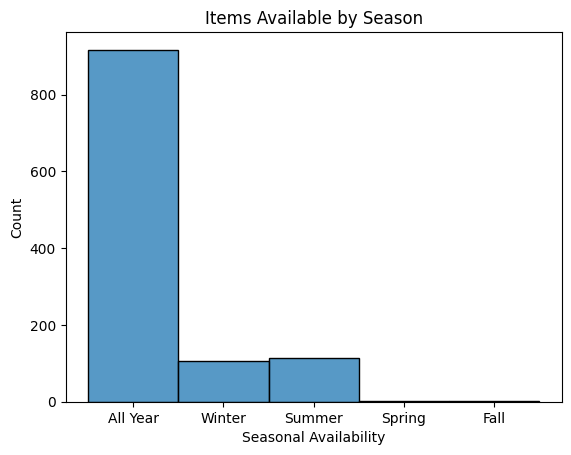

In [ ]:
sns.histplot(wearables["Seasonal Availability"])
plt.title("Items Available by Season")

<Axes: xlabel='Count', ylabel='Source'>

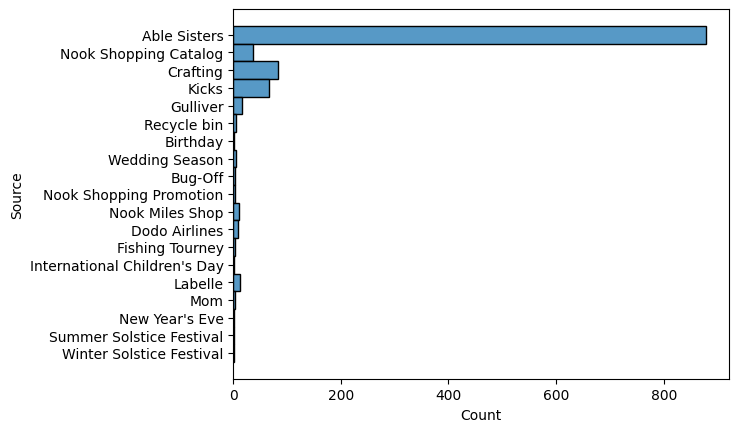

In [ ]:
sns.histplot(y=wearables["Source"])
#plt.xticks(rotation=90);

Text(0.5, 1.0, 'Distribution of DIY vs. Non-DIY Items')

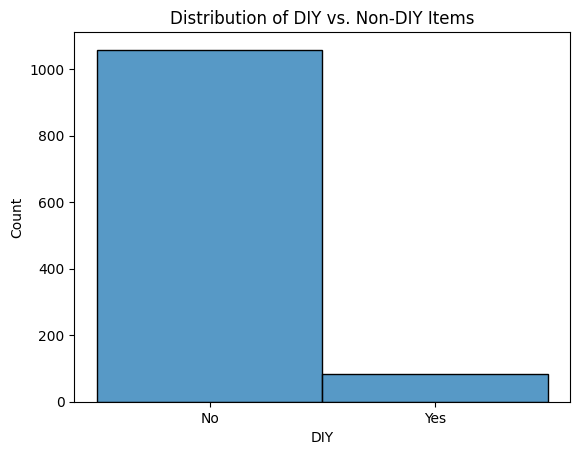

In [ ]:
sns.histplot(wearables["DIY"])
plt.title("Distribution of DIY vs. Non-DIY Items")         

Text(0, 0.5, 'Bells')

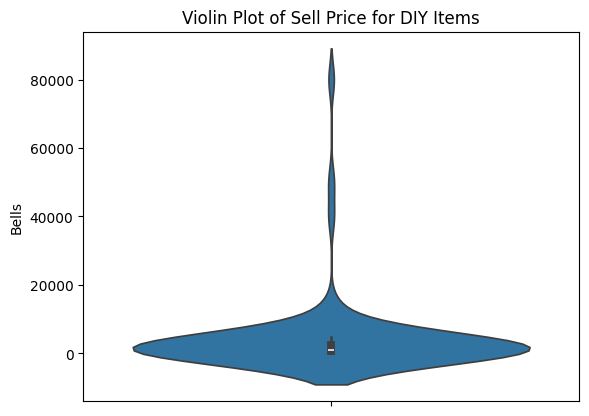

In [ ]:
diy_yes = wearables[wearables["DIY"]=="Yes"]
price = diy_yes["Sell"]
sns.violinplot(y=price)
plt.title("Violin Plot of Sell Price for DIY Items")
plt.ylabel("Bells")

Text(0, 0.5, 'Bells')

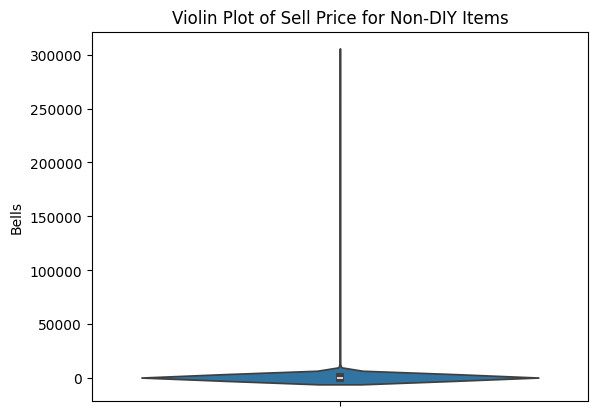

In [ ]:
diy_no = wearables[wearables["DIY"]=="No"]
price = diy_no["Sell"]
sns.violinplot(y=price)
plt.title("Violin Plot of Sell Price for Non-DIY Items")
plt.ylabel("Bells")

(array([723.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 418.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

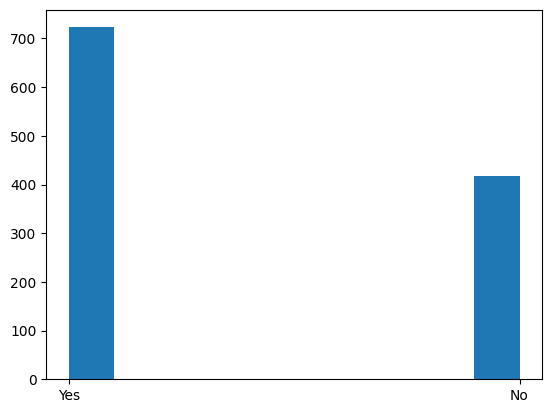

In [ ]:
plt.hist(wearables["Villager Equippable"])

{'whiskers': [<matplotlib.lines.Line2D at 0x127131db0>,
 'caps': [<matplotlib.lines.Line2D at 0x1271322f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x127131b10>],
 'medians': [<matplotlib.lines.Line2D at 0x127132830>],
 'fliers': [<matplotlib.lines.Line2D at 0x127132ad0>],
 'means': []}

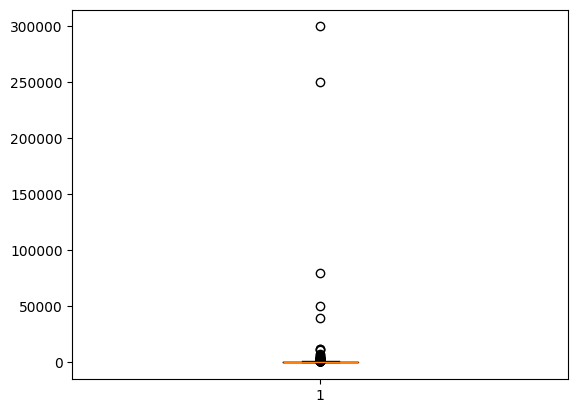

In [ ]:
plt.boxplot(wearables["Sell"])

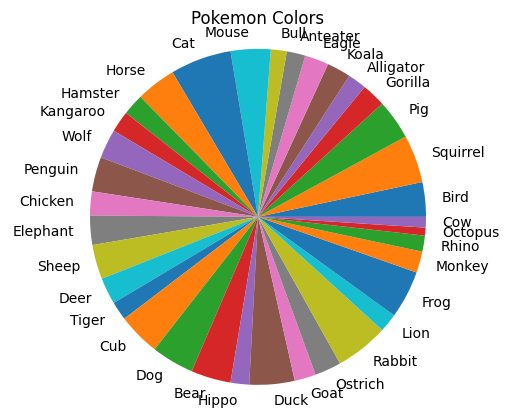

In [ ]:
plt.figure()
animals = dict()
for a in villagers["Species"]:
  if a not in animals:
      animals[a] = 1
  else:
      animals[a] += 1
animalslabels = animals.keys()
animals_vals = [animals[a] for a in animalslabels]
plt.pie(animals_vals, labels=animalslabels)
plt.axis("equal")
plt.title("Pokemon Colors")
plt.show()

In [ ]:
animals_vals

[13,
 18,
 15,
 9,
 7,
 9,
 9,
 7,
 6,
 15,
 23,
 15,
 8,
 8,
 11,
 13,
 9,
 11,
 13,
 10,
 7,
 16,
 16,
 15,
 7,
 17,
 8,
 10,
 20,
 7,
 18,
 8,
 6,
 3,
 4]

In [ ]:
freq_of_vill = pd.DataFrame(list(zip(animalslabels, animals_vals)), columns=['Species', 'Number'])
freq_of_vill["perc"]=freq_of_vill["Number"]/sum(freq_of_vill["Number"])*100
top_n = freq_of_vill.nlargest(8, "Number")  # Returns all columns for the top 5
print(top_n)

     Species  Number      perc
10       Cat      23  5.882353
28    Rabbit      20  5.115090
1   Squirrel      18  4.603581
30      Frog      18  4.603581
25      Duck      17  4.347826
21       Cub      16  4.092072
22       Dog      16  4.092072
2        Pig      15  3.836317


In [ ]:
bottom_n = freq_of_vill.nsmallest(8, "Number")  # Returns all columns for the top 5
print(bottom_n)

      Species  Number      perc
33    Octopus       3  0.767263
34        Cow       4  1.023018
8        Bull       6  1.534527
32      Rhino       6  1.534527
4   Alligator       7  1.790281
7    Anteater       7  1.790281
20      Tiger       7  1.790281
24      Hippo       7  1.790281


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Octopus'),
  Text(1, 0, 'Cow'),
  Text(2, 0, 'Bull'),
  Text(3, 0, 'Rhino'),
  Text(4, 0, 'Alligator'),
  Text(5, 0, 'Anteater'),
  Text(6, 0, 'Tiger'),
  Text(7, 0, 'Hippo')])

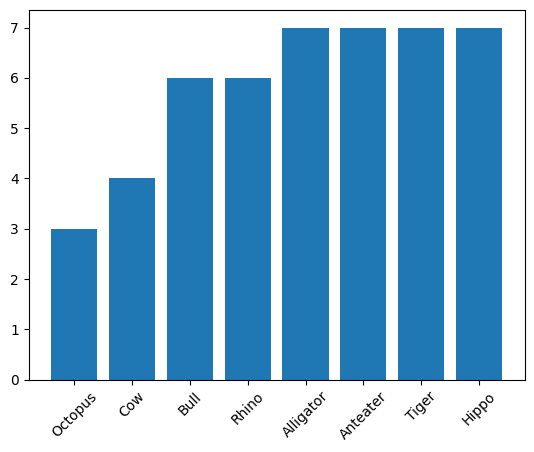

In [ ]:
plt.bar(x=bottom_n["Species"], height=bottom_n["Number"])
plt.xticks(rotation=45)

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Cat'),
  Text(1, 0, 'Rabbit'),
  Text(2, 0, 'Squirrel'),
  Text(3, 0, 'Frog'),
  Text(4, 0, 'Duck'),
  Text(5, 0, 'Cub'),
  Text(6, 0, 'Dog'),
  Text(7, 0, 'Pig')])

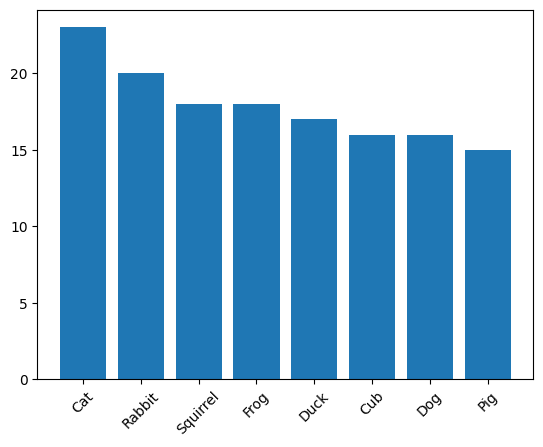

In [ ]:
plt.bar(x=top_n["Species"], height=top_n["Number"])
plt.xticks(rotation=45)

In [ ]:
api_endpoint = "https://api.nookipedia.com/nh/fish"
api_endpoint_2 = "https://api.nookipedia.com/nh/bugs"
api_key = "a34fd9c2-fcf1-4a95-ba6b-9d80aeb3989e"

In [ ]:
query = "%s?api_key=%s" % (api_endpoint, api_key)
response = re.get(query).json()
response

In [ ]:
query = "%s?api_key=%s" % (api_endpoint_2, api_key)
response_2 = re.get(query).json()
response_2

[{'name': 'agrias butterfly',
  'url': 'https://nookipedia.com/wiki/Agrias%20butterfly',
  'number': 10,
  'image_url': 'https://dodo.ac/np/images/6/60/Agrias_Butterfly_NH_Icon.png',
  'render_url': 'https://dodo.ac/np/images/d/db/Agrias_Butterfly_NH.png',
  'location': 'Flying near flowers',
  'weather': 'Any except rain',
  'rarity': '',
  'total_catch': 20,
  'sell_nook': 3000,
  'sell_flick': 4500,
  'tank_width': 1.0,
  'tank_length': 1.0,
  'catchphrases': ['I caught an agrias butterfly! I wonder if it finds me disagrias-able?'],
  'north': {'availability_array': [{'months': 'Apr – Sep',
     'time': '8 AM – 5 PM'}],
   'times_by_month': {'1': 'NA',
    '2': 'NA',
    '3': 'NA',
    '4': '8 AM – 5 PM',
    '5': '8 AM – 5 PM',
    '6': '8 AM – 5 PM',
    '7': '8 AM – 5 PM',
    '8': '8 AM – 5 PM',
    '9': '8 AM – 5 PM',
    '10': 'NA',
    '11': 'NA',
    '12': 'NA'},
   'months': 'Apr – Sep',
   'months_array': [4, 5, 6, 7, 8, 9]},
  'south': {'availability_array': [{'months': '

In [ ]:
bug_data = []

for bug in response_2:
    base = {
        "name": bug["name"],
        "location": bug["location"],
        "weather": bug["weather"],
        "nook_price": bug["sell_nook"],
        "flick_price": bug["sell_flick"]
    }

    # North hemisphere
    for month, time in fish["north"]["times_by_month"].items():
        bug_data.append({
            **base,
            "hemisphere": "north",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

    # South hemisphere
    for month, time in bug["south"]["times_by_month"].items():
        bug_data.append({
            **base,
            "hemisphere": "south",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

bug_data = pd.DataFrame(bug_data)
bug_data

,name,location,weather,nook_price,flick_price,hemisphere,month,time,available
0,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,1,NA,False
1,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,2,NA,False
2,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,3,NA,False
3,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,4,All day,True
4,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,5,All day,True
...,...,...,...,...,...,...,...,...,...
1915,Yellow butterfly,Flying,Any except rain,160,240,south,8,NA,False
1916,Yellow butterfly,Flying,Any except rain,160,240,south,9,4 AM – 7 PM,True
1917,Yellow butterfly,Flying,Any except rain,160,240,south,10,4 AM – 7 PM,True
1918,Yellow butterfly,Flying,Any except rain,160,240,south,11,4 AM – 7 PM,True


<Axes: xlabel='Gender', ylabel='Count'>

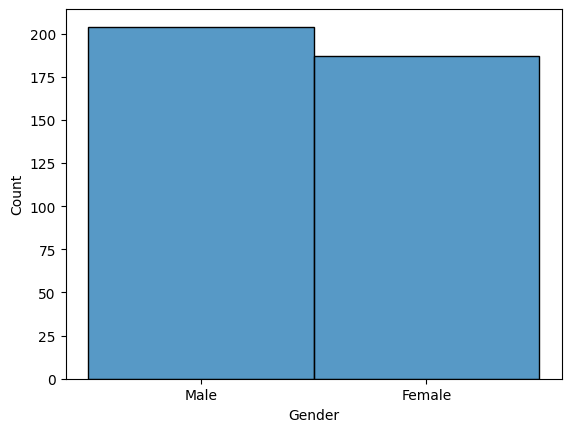

In [ ]:
sns.histplot(villagers["Gender"])

In [ ]:
unique_bug = bug_data.drop_duplicates(subset=["name"]).copy()
unique_bug

,name,location,weather,nook_price,flick_price,hemisphere,month,time,available
0,agrias butterfly,Flying near flowers,Any except rain,3000,4500,north,1,NA,False
24,ant,On/near spoiled turnips/candy/lollipops,Any weather,80,120,north,1,NA,False
48,Atlas moth,On trees (any kind),Any weather,3000,4500,north,1,NA,False
72,bagworm,Shaking trees (hardwood and cedar),Any weather,600,900,north,1,NA,False
96,banded dragonfly,Flying near water,Any except rain,4500,6750,north,1,NA,False
...,...,...,...,...,...,...,...,...,...
1800,walking leaf,Disguised under trees,Any weather,600,900,north,1,NA,False
1824,walking stick,On trees (any kind),Any weather,600,900,north,1,NA,False
1848,wasp,Shaking non-fruit hardwood trees or cedar trees,Any weather,2500,3750,north,1,NA,False
1872,wharf roach,On beach rocks,Any weather,200,300,north,1,NA,False


In [ ]:
fish_data = []

for fish in response:
    base = {
        "name": fish["name"],
        "location": fish["location"],
        "shadow_size": fish["shadow_size"],
        "rarity": fish["rarity"],
        "nook_price": fish["sell_nook"],
        "cj_price": fish["sell_cj"]
    }

    # North hemisphere
    for month, time in fish["north"]["times_by_month"].items():
        fish_data.append({
            **base,
            "hemisphere": "north",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

    # South hemisphere
    for month, time in fish["south"]["times_by_month"].items():
        fish_data.append({
            **base,
            "hemisphere": "south",
            "month": int(month),
            "time": time,
            "available": time != "NA"
        })

fish_data = pd.DataFrame(fish_data)
fish_data

,name,location,shadow_size,rarity,nook_price,cj_price,hemisphere,month,time,available
0,Anchovy,Sea,Small,Uncommon,200,300,north,1,4 AM – 9 PM,True
1,Anchovy,Sea,Small,Uncommon,200,300,north,2,4 AM – 9 PM,True
2,Anchovy,Sea,Small,Uncommon,200,300,north,3,4 AM – 9 PM,True
3,Anchovy,Sea,Small,Uncommon,200,300,north,4,4 AM – 9 PM,True
4,Anchovy,Sea,Small,Uncommon,200,300,north,5,4 AM – 9 PM,True
...,...,...,...,...,...,...,...,...,...,...
1915,Zebra turkeyfish,Sea,Medium,Common,500,750,south,8,NA,False
1916,Zebra turkeyfish,Sea,Medium,Common,500,750,south,9,NA,False
1917,Zebra turkeyfish,Sea,Medium,Common,500,750,south,10,All day,True
1918,Zebra turkeyfish,Sea,Medium,Common,500,750,south,11,All day,True


In [ ]:
unique_fish = fish_data.drop_duplicates(subset=["name"]).copy()
unique_fish['shadow_size'] = pd.Categorical(unique_fish['shadow_size'], categories=['Tiny', 'Small', 'Medium', 'Large',
                                                                                    'Very large', "Huge", 'Very large (finned)', 'Long'], ordered=True)

Text(0.5, 0, 'Shadow Size')

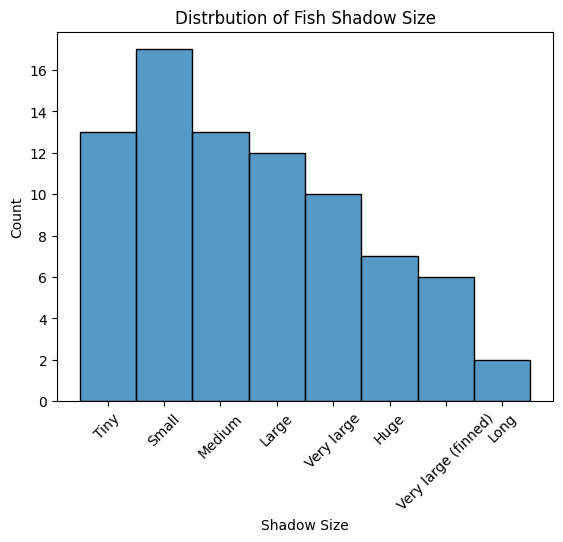

In [ ]:
sns.histplot(unique_fish["shadow_size"])
plt.xticks(rotation=45)
plt.title("Distrbution of Fish Shadow Size")
plt.xlabel("Shadow Size")

Text(0.5, 0, 'Weather')

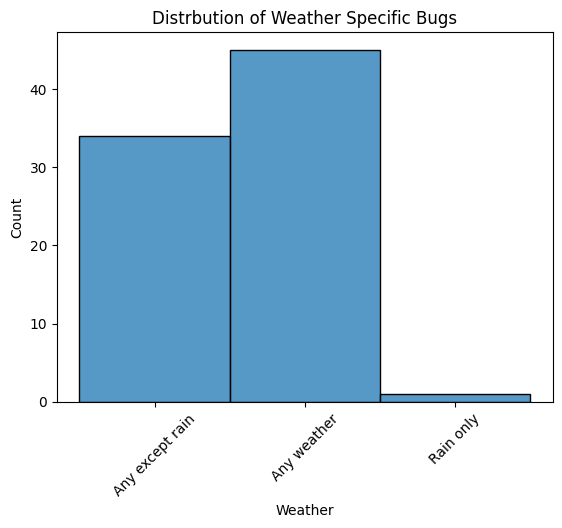

In [ ]:
sns.histplot(unique_bug["weather"])
plt.xticks(rotation=45)
plt.title("Distrbution of Weather Specific Bugs")
plt.xlabel("Weather")

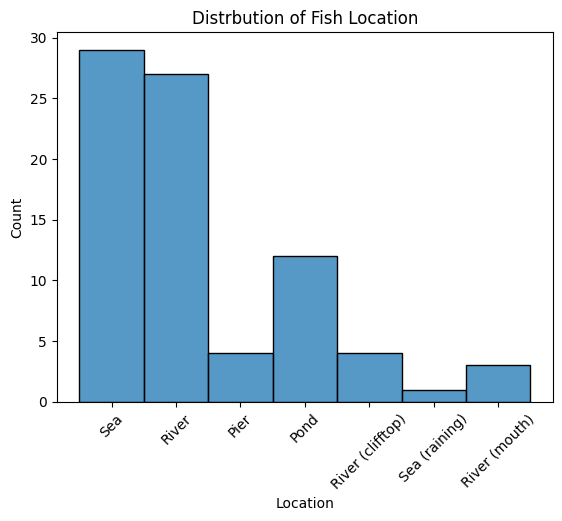

In [ ]:
sns.histplot(unique_fish["location"])
plt.xticks(rotation=45)
plt.title("Distrbution of Fish Location")
plt.xlabel("Location");

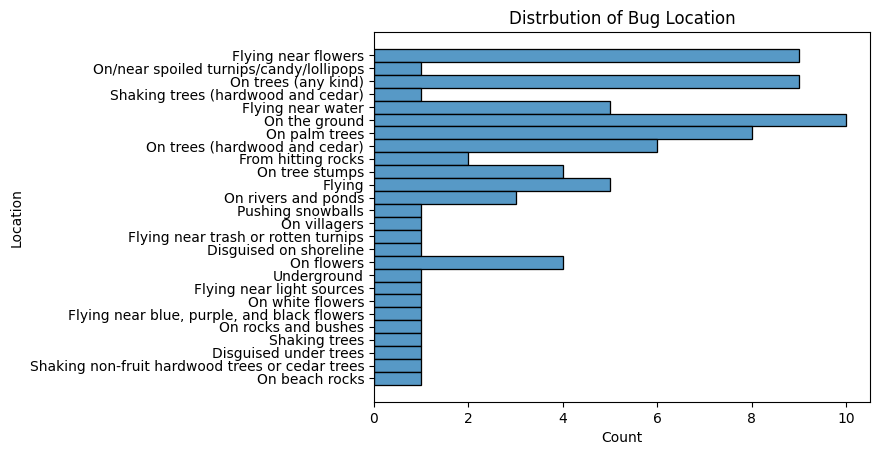

In [ ]:
sns.histplot(y=unique_bug["location"])
#plt.xticks(rotation=90)
plt.title("Distrbution of Bug Location")
plt.ylabel("Location");

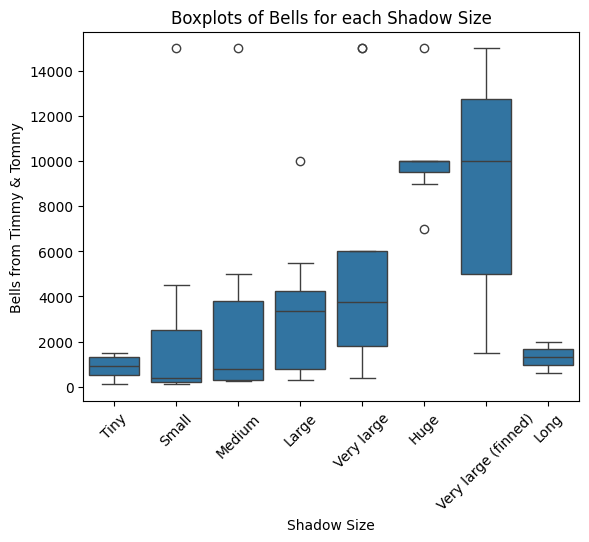

In [ ]:
sns.boxplot(data=unique_fish, x="shadow_size", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Shadow Size")
plt.title("Boxplots of Bells for each Shadow Size");

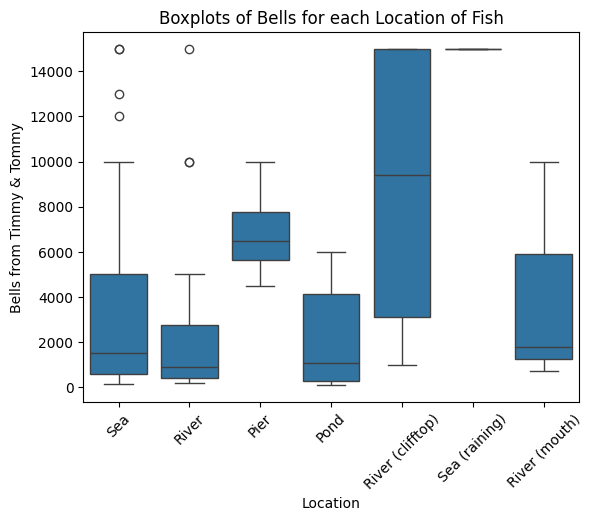

In [ ]:
sns.boxplot(data=unique_fish, x="location", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Location")
plt.title("Boxplots of Bells for each Location of Fish");

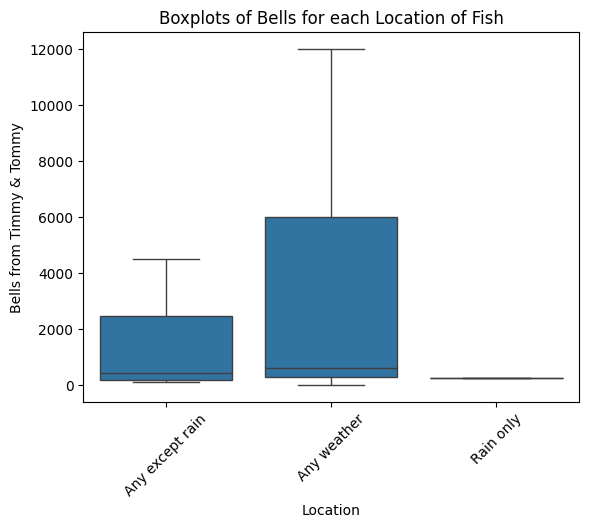

In [ ]:
sns.boxplot(data=unique_bug, x="weather", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Location")
plt.title("Boxplots of Bells for each Location of Fish");

In [ ]:
sns.boxplot(data=unique_fish, x="shadow_size", y="nook_price")
plt.xticks(rotation=45)
plt.ylabel("Bells from Timmy & Tommy")
plt.xlabel("Shadow Size")
plt.title("Boxplots of Bells for each Shadow Size");

NameError: name 'unique_fish' is not defined

In [178]:
path="/Users/mattgonzales/downloads/Labeled Turnips - turnip_weekly_clean.csv"
turnip=pd.read_csv(path)

In [179]:
turnip = turnip.dropna()
turnip.isna().sum()


week            0
Sunday_AM       0
Monday_AM       0
Monday_PM       0
Tuesday_AM      0
Tuesday_PM      0
Wednesday_AM    0
Wednesday_PM    0
Thursday_AM     0
Thursday_PM     0
Friday_AM       0
Friday_PM       0
Saturday_AM     0
Saturday_PM     0
Label           0
dtype: int64

In [180]:
OriginalTurnips = turnip.copy()
OriginalTurnips = OriginalTurnips.drop("week", axis=1)
TurnipLabel = turnip["Label"]
turnip=turnip.drop(["week", "Label"], axis=1)
feature_names = turnip.columns
print(OriginalTurnips)
print(turnip)

     Sunday_AM  Monday_AM  Monday_PM  Tuesday_AM  Tuesday_PM  Wednesday_AM  \
0         96.0       92.0       87.0        82.0          79            74   
1        109.0       88.0       84.0        80.0          76            73   
2        106.0       96.0       91.0        86.0          83            79   
4        107.0       80.0       99.0       123.0         168           183   
6         96.0       86.0       83.0       132.0         139           512   
..         ...        ...        ...         ...         ...           ...   
105      110.0       98.0       94.0        90.0          86            81   
106      108.0      141.0      110.0       151.0         115           144   
107      106.0      103.0       77.0        69.0          64           117   
108      103.0      110.0      138.0       118.0         108           144   
109       93.0       75.0       66.0        58.0         129            98   

     Wednesday_PM  Thursday_AM  Thursday_PM  Friday_AM  Friday_

In [194]:

scaler = StandardScaler()

turnip = scaler.fit_transform(turnip)
print(turnip)

[[-0.73192082  0.1935879   0.0414356  ...  0.70669641  0.34108585
   0.47101806]
 [ 1.42868387 -0.01946122 -0.10547243 ...  0.73006571  2.68105449
   3.02933097]
 [ 0.93008279  0.40663702  0.23731297 ... -0.52019148 -0.6297522
  -0.69185145]
 ...
 [ 0.93008279  0.77947299 -0.44825782 ...  0.36784166  0.98831122
   1.8955332 ]
 [ 0.4314817   1.15230895  2.53887204 ... -0.23975996 -0.10699325
  -0.13948843]
 [-1.2305219  -0.71187086 -0.98692059 ... -0.37997572 -0.35592608
   1.34317019]]


In [182]:
MyDic = {
    "Fluctuating": 0,
    "Small Spike": 1,
    "Large Spike": 2,
    "Decreasing": 3,
}
TurnipLabel = TurnipLabel.map(MyDic)

In [183]:
My2DPCA=PCA(n_components=2)
TwoDResult = My2DPCA.fit_transform(turnip)
print(TwoDResult)
print("The eigenvalues:", My2DPCA.explained_variance_)

[[-1.38966495 -0.16268728]
 [-2.6511018  -2.49235998]
 [ 0.8397878  -0.52363674]
 [ 3.14094772  0.10826049]
 [ 2.81813551  0.39120588]
 [-1.4488723  -1.41216478]
 [-2.65154117 -1.0714653 ]
 [ 0.90277956 -0.6351026 ]
 [ 1.44423637  2.67939225]
 [-1.29390096  1.19514898]
 [ 0.22171296  0.67535506]
 [ 0.43530906  0.06131178]
 [-3.3709722  -0.761433  ]
 [ 0.17338352 -1.89177635]
 [-2.03885863  0.44095543]
 [ 0.35189059 -2.53924738]
 [ 1.35086742  2.13009259]
 [-4.262924   -1.6178003 ]
 [ 1.46954488  1.19144178]
 [-3.29937807 -2.07437551]
 [ 0.13451882  0.58445586]
 [-0.77234052  1.62726012]
 [ 1.81635699  2.4782693 ]
 [-2.91064566 -0.02563602]
 [ 0.31543706 -1.7150605 ]
 [ 0.96200275 -0.95101892]
 [-1.96675205  2.88355702]
 [-1.78852249  2.19767368]
 [-2.40192819  0.73666302]
 [-3.47750861 -0.02806767]
 [ 0.80771119 -0.56461236]
 [-2.2844216   0.5694369 ]
 [ 1.3149253   1.75803606]
 [-2.17349327 -0.68285213]
 [ 0.41047301  0.17261315]
 [ 0.10702921  1.55488452]
 [ 0.82627289 -0.4386857 ]
 

In [184]:
MyPCA=PCA(n_components=3)
Result=MyPCA.fit_transform(turnip)
print(Result)
print("The eigenvalues:", MyPCA.explained_variance_)

[[-1.38966495 -0.16268728  0.38929774]
 [-2.6511018  -2.49235998  0.84585107]
 [ 0.8397878  -0.52363674 -0.81078208]
 [ 3.14094772  0.10826049 -0.19805183]
 [ 2.81813551  0.39120588  1.07849038]
 [-1.4488723  -1.41216478 -0.25939975]
 [-2.65154117 -1.0714653  -0.60993283]
 [ 0.90277956 -0.6351026  -0.61133325]
 [ 1.44423637  2.67939225  2.03552294]
 [-1.29390096  1.19514898 -0.1825023 ]
 [ 0.22171296  0.67535506 -2.65652866]
 [ 0.43530906  0.06131178 -1.68167272]
 [-3.3709722  -0.761433    1.64457935]
 [ 0.17338352 -1.89177635 -0.03102247]
 [-2.03885863  0.44095543 -1.78156567]
 [ 0.35189059 -2.53924738  1.52958495]
 [ 1.35086742  2.13009259 -0.96254092]
 [-4.262924   -1.6178003  -0.64223339]
 [ 1.46954488  1.19144178  1.67067957]
 [-3.29937807 -2.07437551  0.11667415]
 [ 0.13451882  0.58445586 -2.47442974]
 [-0.77234052  1.62726012  0.58139872]
 [ 1.81635699  2.4782693  -0.39585863]
 [-2.91064566 -0.02563602  0.48537611]
 [ 0.31543706 -1.7150605  -0.7465315 ]
 [ 0.96200275 -0.95101892

In [185]:
My95PCA=PCA(n_components=10)
big95Result = My95PCA.fit_transform(turnip)
print("The relative eigenvalues are:",My95PCA.explained_variance_ratio_)
cumulative_variance95 = np.cumsum(My95PCA.explained_variance_ratio_) * 100  # percentage
print("Cumulative variance (%) for each PC:", cumulative_variance95)

The relative eigenvalues are: [0.27037648 0.18221242 0.1148104  0.11351012 0.08352771 0.05351934
 0.04942051 0.0343103  0.02820104 0.02270799]
Cumulative variance (%) for each PC: [27.03764843 45.25889063 56.73993103 68.09094266 76.44371357 81.79564769
 86.73769856 90.16872883 92.98883302 95.25963215]


In [186]:
My2DCov=np.cov(TwoDResult.T)
print("Covar of the PC PCA Matrix: \n", My2DCov) ## The variance here (on the diagonal) will match the eigenvalues
print("The relative eigenvalues are:",My2DPCA.explained_variance_ratio_)
cumulative_variance_3 = np.cumsum(My2DPCA.explained_variance_ratio_) * 100  # percentage
print("Cumulative variance (%) for each PC:", cumulative_variance_3)
print("The actual eigenvalues are:", My2DPCA.explained_variance_)
EVects2D=My2DPCA.components_
print("The eigenvectors are:\n",EVects2D)
print(type(EVects2D))
print("The shape of the eigenvector matrix is\n", EVects2D.shape)
print(turnip.shape)
print(turnip)

Covar of the PC PCA Matrix: 
 [[3.54901948e+00 1.09834641e-15]
 [1.09834641e-15 2.39175917e+00]]
The relative eigenvalues are: [0.27037648 0.18221242]
Cumulative variance (%) for each PC: [27.03764843 45.25889063]
The actual eigenvalues are: [3.54901948 2.39175917]
The eigenvectors are:
 [[ 0.10727017  0.11633926  0.25144109  0.39386335  0.30349027  0.28917332
   0.21622861 -0.04434196 -0.26790737 -0.3289142  -0.35402743 -0.37583711
  -0.2925934 ]
 [-0.16454696 -0.38895348 -0.3981769  -0.22446683 -0.09834353  0.06653701
   0.34825536  0.43566753  0.26474335 -0.02017644 -0.21352193 -0.2825493
  -0.30265628]]
<class 'numpy.ndarray'>
The shape of the eigenvector matrix is
 (2, 13)
(104, 13)
[[-0.73192082  0.1935879   0.0414356  ...  0.70669641  0.34108585
   0.47101806]
 [ 1.42868387 -0.01946122 -0.10547243 ...  0.73006571  2.68105449
   3.02933097]
 [ 0.93008279  0.40663702  0.23731297 ... -0.52019148 -0.6297522
  -0.69185145]
 ...
 [ 0.93008279  0.77947299 -0.44825782 ...  0.36784166  0

In [187]:
MyCov=np.cov(Result.T)
print("Covar of the PC PCA Matrix: \n", MyCov) ## The variance here (on the diagonal) will match the eigenvalues
print("The relative eigenvalues are:",MyPCA.explained_variance_ratio_)
cumulative_variance = np.cumsum(MyPCA.explained_variance_ratio_) * 100  # percentage
print("Cumulative variance (%) for each PC:", cumulative_variance)
print("The actual eigenvalues are:", MyPCA.explained_variance_)
EVects=MyPCA.components_
print("The eigenvectors are:\n",EVects)
print(type(EVects))
print("The shape of the eigenvector matrix is\n", EVects.shape)
print(turnip.shape)
print(turnip)

Covar of the PC PCA Matrix: 
 [[ 3.54901948e+00  1.09834641e-15 -1.19908990e-16]
 [ 1.09834641e-15  2.39175917e+00 -9.55446573e-17]
 [-1.19908990e-16 -9.55446573e-17  1.50702589e+00]]
The relative eigenvalues are: [0.27037648 0.18221242 0.1148104 ]
Cumulative variance (%) for each PC: [27.03764843 45.25889063 56.73993103]
The actual eigenvalues are: [3.54901948 2.39175917 1.50702589]
The eigenvectors are:
 [[ 0.10727017  0.11633926  0.25144109  0.39386335  0.30349027  0.28917332
   0.21622861 -0.04434196 -0.26790737 -0.3289142  -0.35402743 -0.37583711
  -0.2925934 ]
 [-0.16454696 -0.38895348 -0.3981769  -0.22446683 -0.09834353  0.06653701
   0.34825536  0.43566753  0.26474335 -0.02017644 -0.21352193 -0.2825493
  -0.30265628]
 [ 0.31327171  0.35709898  0.26090011  0.12768283  0.0180621   0.20679968
   0.41187755  0.45381602  0.37173059  0.24135418  0.06622648  0.16489136
   0.20802491]]
<class 'numpy.ndarray'>
The shape of the eigenvector matrix is
 (3, 13)
(104, 13)
[[-0.73192082  0.19

In [188]:
threshold = 0.4
# Find features with loadings above the threshold for each principal component
important_features = {}
for column in loadings.columns:
    important_features[column] = loadings.index[loadings[column].abs() > threshold].tolist()


In [189]:
for i, comp in enumerate(MyPCA2.components_):
    print(f"PC{i+1}:", comp)

PC1: [ 0.10727017  0.11633926  0.25144109  0.39386335  0.30349027  0.28917332
  0.21622861 -0.04434196 -0.26790737 -0.3289142  -0.35402743 -0.37583711
 -0.2925934 ]
PC2: [-0.16454696 -0.38895348 -0.3981769  -0.22446683 -0.09834353  0.06653701
  0.34825536  0.43566753  0.26474335 -0.02017644 -0.21352193 -0.2825493
 -0.30265628]
PC3: [0.31327171 0.35709898 0.26090011 0.12768283 0.0180621  0.20679968
 0.41187755 0.45381602 0.37173059 0.24135418 0.06622648 0.16489136
 0.20802491]


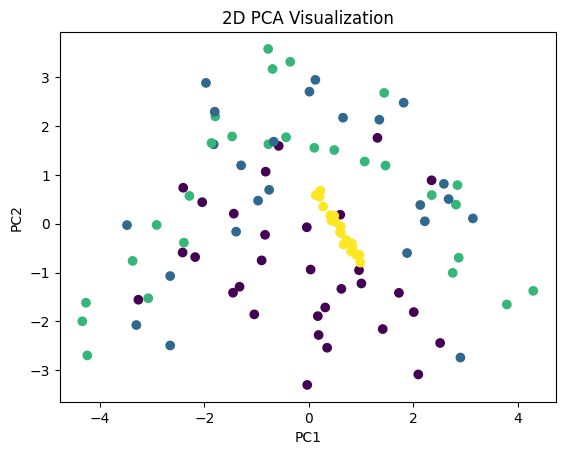

In [190]:
plt.scatter(TwoDResult[:,0], TwoDResult[:,1], c=TurnipLabel)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Visualization")
plt.savefig("2D_PCA.png")
# plt.show()



[-0.16268728 -2.49235998 -0.52363674  0.10826049  0.39120588 -1.41216478
 -1.0714653  -0.6351026   2.67939225  1.19514898  0.67535506  0.06131178
 -0.761433   -1.89177635  0.44095543 -2.53924738  2.13009259 -1.6178003
  1.19144178 -2.07437551  0.58445586  1.62726012  2.4782693  -0.02563602
 -1.7150605  -0.95101892  2.88355702  2.19767368  0.73666302 -0.02806767
 -0.56461236  0.5694369   1.75803606 -0.68285213  0.17261315  1.55488452
 -0.4386857   1.77077042  0.20610092  0.58680173 -0.58939046 -0.38712107
  1.5940887  -1.55620168 -1.33356721 -1.00579193 -1.85609055  0.55241448
 -1.3748645   0.18395368 -1.52557756 -0.42610523  0.38361194  3.57947005
 -0.75062142 -0.600456   -1.99798561 -0.65010468 -3.08626794  1.67977135
  0.81647639 -1.80950688 -0.33260292  0.50467672 -2.74047108  0.03670874
 -0.05648848  1.78746417 -0.07232867  0.88923011  3.31579934  0.04995099
  2.94593171  1.27429454 -0.22687582 -0.93827644  0.16310087  3.16859907
  1.62620357 -1.65342378 -1.2235918   0.35224885  2.

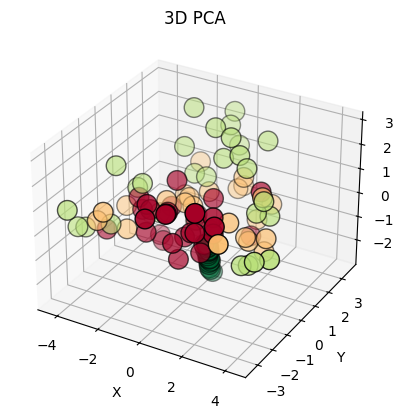

In [191]:
fig2 = plt.figure()
    #figsize=(12, 12))
ax2 = fig2.add_subplot(projection='3d')
#Axes3D(fig2, rect=[0, 0, .90, 1], elev=48, azim=134)

x=Result[:,0]
y=Result[:,1] 
z=Result[:,2]
print(y)

ax2.scatter(x,y,z, cmap="RdYlGn", edgecolor='k', s=200, c=TurnipLabel)
#surf2 = ax2.plot_surface(x, y, z, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D PCA')
#
plt.savefig("3D_PCA.png")
# plt.show()

[3.54901948 5.94077865 7.44780454]
[0.27037648 0.18221242 0.1148104 ]


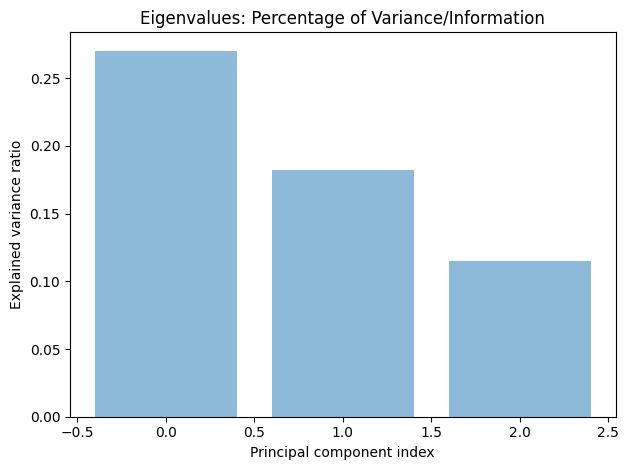

In [192]:
fig3=plt.figure()
ACCUM_eigenvalues = np.cumsum(MyPCA.explained_variance_)
print(ACCUM_eigenvalues)
print(MyPCA.explained_variance_ratio_)
plt.bar(range(0,len(MyPCA.explained_variance_ratio_)), MyPCA.explained_variance_ratio_, 
        alpha=0.5, align='center', label='Individual Explained Variances')
#plt.step(range(0,len(ACCUM_eigenvalues)), ACCUM_eigenvalues, where='mid',label='Cumulative Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues: Percentage of Variance/Information")
#plt.legend(loc='best')

plt.tight_layout()
plt.show()


Cluster Centers (in PCA space):
 [[-2.23551428 -0.46345073 -0.0511001 ]
 [ 1.15700376 -0.0058432  -0.81690739]
 [-0.18885952  2.21960327  1.22793891]
 [ 1.69689242 -2.15565585  0.96248262]]


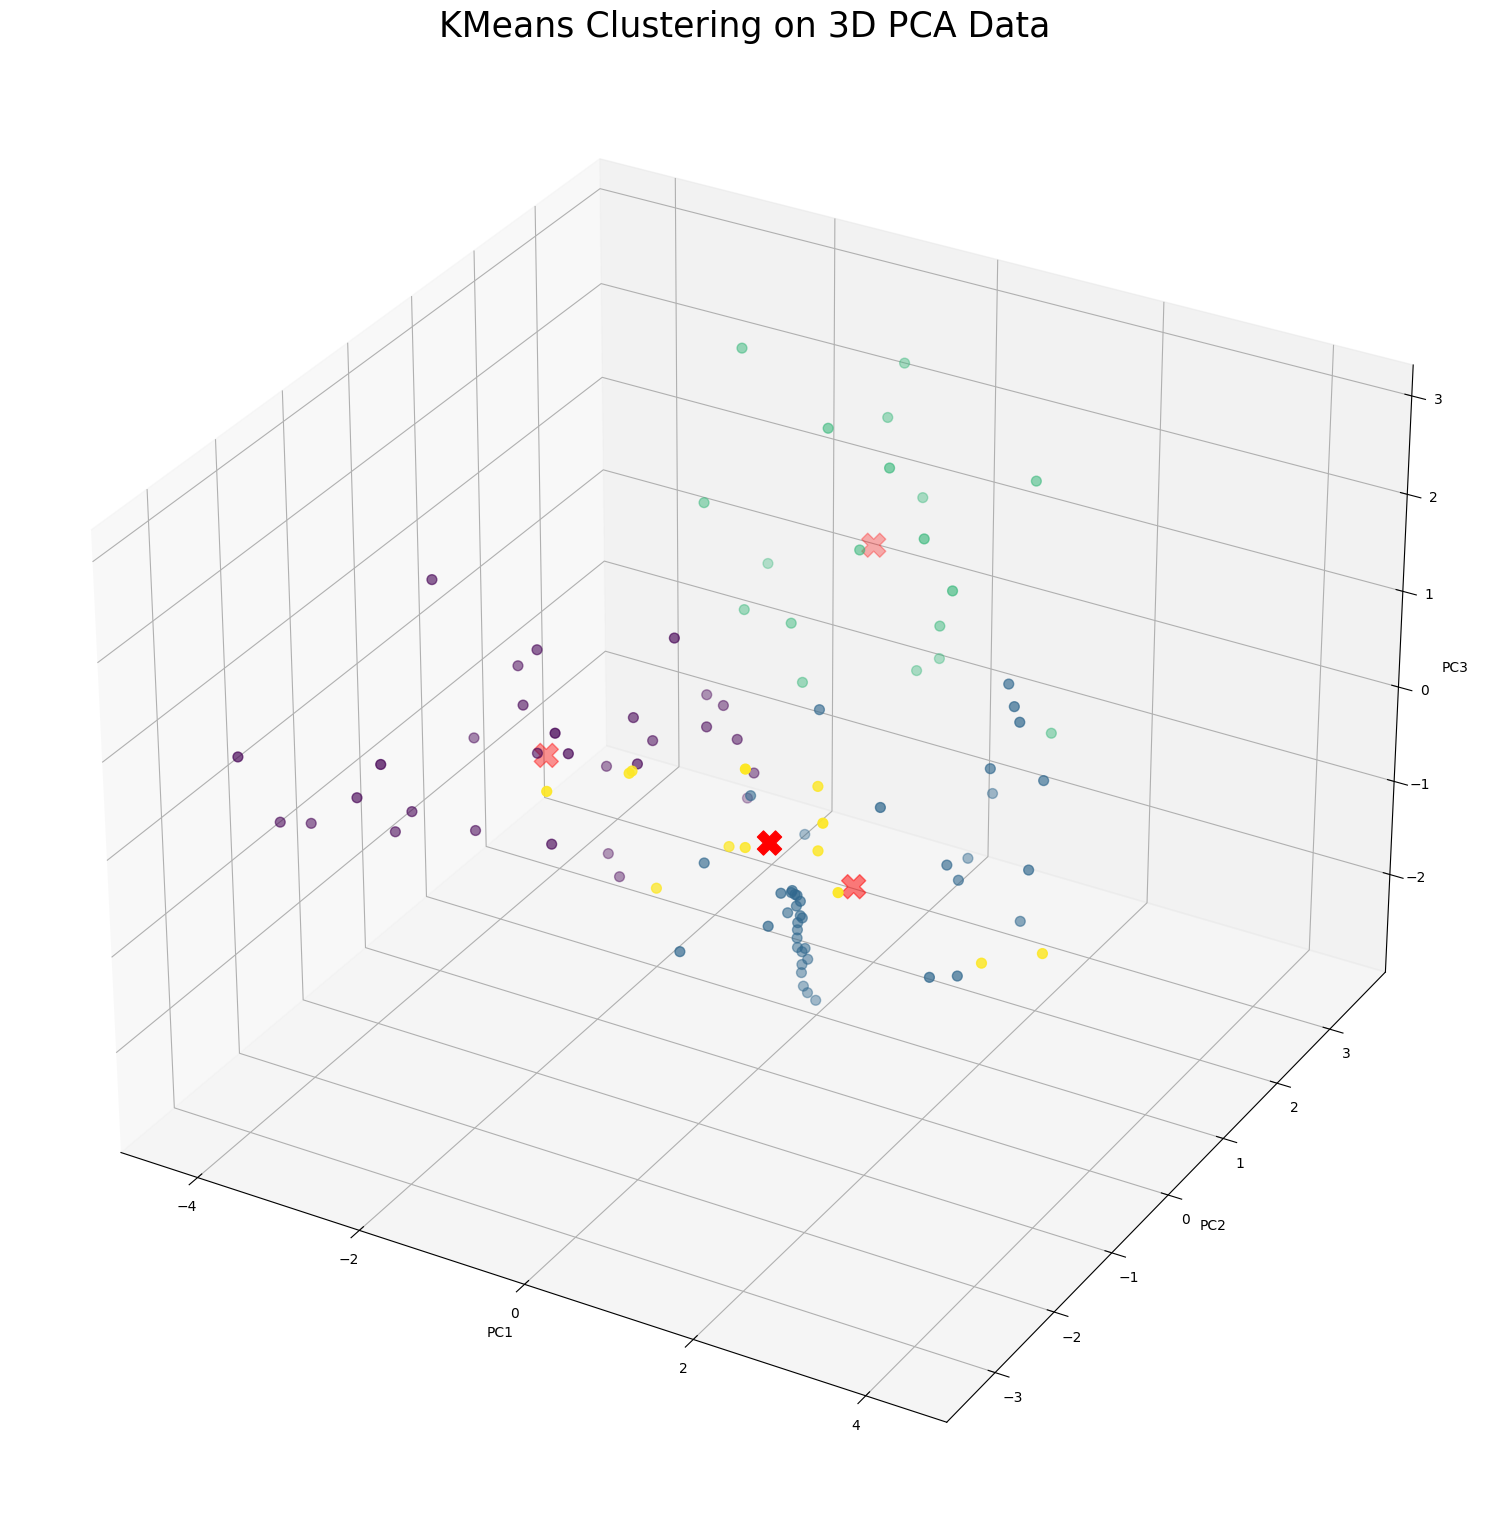

In [197]:
from sklearn.cluster import KMeans

DF3D = Result[:, 0:3]

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(DF3D)

labels_3D = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster Centers (in PCA space):\n", centroids)

# %%
fig = plt.figure(figsize=(15, 40))
ax = fig.add_subplot(projection='3d')

x = DF3D[:, 0]
y = DF3D[:, 1]
z = DF3D[:, 2]

scatter = ax.scatter(x, y, z, c=labels_3D, cmap="viridis", s=50)

# Plot centroids
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    s=300,
    c='red',
    marker='X'
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clustering on 3D PCA Data', fontsize=25)
plt.tight_layout()
plt.savefig("KMeans_3D.png")
plt.show()